In [36]:
import os
import random
import re
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from transformers import BertTokenizer, BertForSequenceClassification

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train_path = "/content/drive/MyDrive/Colab Notebooks/Certifications/GenAI-Pinnacle-Analytics-Vidhya/Sentiment Analysis - Finetuning BERT/data/train.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/Certifications/GenAI-Pinnacle-Analytics-Vidhya/Sentiment Analysis - Finetuning BERT/data/test.csv"

In [4]:
# read the dataset
df_train = pd.read_csv(train_path, encoding="Windows-1252")
df_train.rename(columns={
    "sentiment": "polarity",
}, inplace=True)
df_train = df_train[["text", "polarity"]]

# read the dataset
df_test = pd.read_csv(test_path, encoding="Windows-1252")
df_test.rename(columns={
    "sentiment": "polarity",
}, inplace=True)
df_test = df_test[["text", "polarity"]]

# convert target variables into pytorch tensors
label_map = {"negative": 0, "neutral":1, "positive": 2}

df_train["polarity"] = df_train["polarity"].map(label_map)
df_test["polarity"] = df_test["polarity"].map(label_map)

df_test.head()

,text,polarity
0,Last session of the day http://twitpic.com/67ezh,1.0
1,Shanghai is also really exciting (precisely -...,2.0
2,"Recession hit Veronique Branquinho, she has to...",0.0
3,happy bday!,2.0
4,http://twitpic.com/4w75p - I like it!!,2.0


In [5]:
before = len(df_train)
df_train.dropna(how="any", inplace=True)
print(f"{before - len(df_train)} NaN rows dropped.")

1 NaN rows dropped.


In [6]:
before = len(df_test)
df_test.dropna(how="any", inplace=True)
print(f"{before - len(df_test)} NaN rows dropped.")
df_test['polarity'] = df_test['polarity'].astype('int')

1281 NaN rows dropped.


In [7]:

def text_preprocess(text):
    # Check if the text is a string
    if not isinstance(text, str):
        raise ValueError("Should be a str")

    # Remove urls
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    return text

# Just to not change the proprocessing for now
def text_preprocess(text):
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"#\w+", "", text)  # remove hashtags
    text = re.sub(r"@\w+", "", text)  # remove mentions
    # text = re.sub(r"[^\w\s]", "", text)  # remove special characters
    text = re.sub(r"[^\w\s,.!?'\":;()\-]", "", text)
    text = text.strip()  # remove extra whitespace

    return text

In [8]:
#apply the text_preprocess to
df_train["text_preprocessed"] = df_train["text"].apply(text_preprocess)
df_test["text_preprocessed"] = df_test["text"].apply(text_preprocess)

In [9]:
before = len(df_train)
df_train.drop_duplicates(subset=["text", "polarity"], inplace=True)
print(f"{before - len(df_train)} rows are dropped")
print(f"dataset has {len(df_train)} rows")

0 rows are dropped
dataset has 27480 rows


In [10]:
before = len(df_test)
df_test.drop_duplicates(subset=["text", "polarity"], inplace=True)
print(f"{before - len(df_test)} rows are dropped")
print(f"dataset has {len(df_test)} rows")

0 rows are dropped
dataset has 3534 rows


In [11]:
def is_garbled(text, threshold=0.5):
    non_alpha_ratio = len(re.findall(r'[^a-zA-Z\s]', text)) / max(len(text), 1)
    return non_alpha_ratio > threshold

In [12]:
before = len(df_train)
df_train = df_train[~df_train["text"].apply(is_garbled)]
print(f"{before - len(df_train)} rows are dropped")
print(f"dataset has {len(df_train)} rows")

18 rows are dropped
dataset has 27462 rows


In [13]:
before = len(df_test)
df_test = df_test[~df_test["text"].apply(is_garbled)]
print(f"{before - len(df_test)} rows are dropped")
print(f"dataset has {len(df_test)} rows")

1 rows are dropped
dataset has 3533 rows


In [14]:
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=3, ignore_mismatched_sizes=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
# Freeze all base model parameters except for pooling layers parameters and last 5 encoding layers
for name, param in model.base_model.named_parameters():
    if not name.startswith("pooler"):
        param.requires_grad = False

# Unfreeze the last 4 layers of the encoder
for layer in model.bert.encoder.layer[-4:]:
    for param in layer.parameters():
        param.requires_grad = True

In [16]:
# Print trainable params summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable_params} / {total_params} ({100 * trainable_params/total_params:.2f}%)")

Trainable params: 28944387 / 109484547 (26.44%)


In [17]:
class CustomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }


In [18]:
# Set maximum sequence length
MAX_LEN = 64

In [19]:
# Create DataLoaders for train and val sets
train_dataset = CustomDataset(df_train['text_preprocessed'], df_train['polarity'], tokenizer, MAX_LEN)
test_dataset = CustomDataset(df_test['text_preprocessed'], df_test['polarity'], tokenizer, MAX_LEN)

In [20]:
# Define training parameters
batch_size = 16
epochs = 5
lr = 2e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

In [21]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [22]:
# Training loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [23]:
def compute_metrics_from_preds(labels, preds):
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

In [24]:
best_val_loss = float('inf')  # Initialize best_val_loss to a very high value
best_epoch = -1  # Initialize best_epoch to an invalid value to track the epoch of the best validation loss

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    total_val_loss = 0

    # Training
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} [Training]", leave=True)

    for batch in train_loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        avg_train_loss = total_train_loss / (train_loop.n + 1)

        # Update the postfix to show the current average training loss
        train_loop.set_postfix(train_loss=avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(test_loader)

    # Check if the current validation loss is the lowest; if so, save the model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_model.pth')  # Save the best model

    print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")


Epoch 1/5 [Training]: 100%|██████████| 1717/1717 [02:56<00:00,  9.75it/s, train_loss=0.636]


Epoch finished with Avg. Train Loss: 0.6363
Epoch 1/5, Training Loss: 0.6363, Validation Loss: 0.5338


Epoch 2/5 [Training]: 100%|██████████| 1717/1717 [02:49<00:00, 10.10it/s, train_loss=0.522]


Epoch finished with Avg. Train Loss: 0.5219
Epoch 2/5, Training Loss: 0.5222, Validation Loss: 0.5317


Epoch 3/5 [Training]: 100%|██████████| 1717/1717 [02:50<00:00, 10.10it/s, train_loss=0.469]


Epoch finished with Avg. Train Loss: 0.4689
Epoch 3/5, Training Loss: 0.4689, Validation Loss: 0.5547


Epoch 4/5 [Training]: 100%|██████████| 1717/1717 [02:49<00:00, 10.11it/s, train_loss=0.408]


Epoch finished with Avg. Train Loss: 0.4079
Epoch 4/5, Training Loss: 0.4079, Validation Loss: 0.5610


Epoch 5/5 [Training]: 100%|██████████| 1717/1717 [02:50<00:00, 10.07it/s, train_loss=0.332]


Epoch finished with Avg. Train Loss: 0.3325
Epoch 5/5, Training Loss: 0.3325, Validation Loss: 0.6075


In [27]:
# Load saved weights
best_model_path = "best_model.pth"
model.load_state_dict(torch.load(best_model_path))
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [31]:
model.eval()
all_preds = []
all_labels = []
val_loss = 0.0
val_steps = 0

with torch.no_grad():
    val_iter = tqdm(test_loader, leave=True)
    for batch in val_iter:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        val_loss += loss.item()
        val_steps += 1

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

        val_iter.set_postfix(val_loss=f"{(val_loss/val_steps):.4f}")

metrics = compute_metrics_from_preds(all_labels, all_preds)

100%|██████████| 221/221 [00:13<00:00, 16.15it/s, val_loss=0.5317]


In [32]:
metrics

{'accuracy': 0.777809227285593,
 'precision': 0.7867682756146359,
 'recall': 0.777809227285593,
 'f1': 0.7793682163653299}

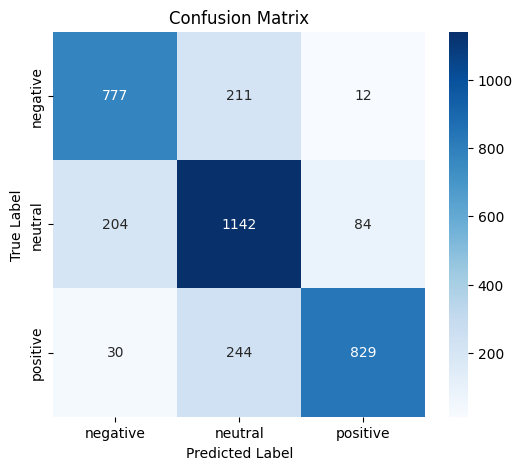

In [37]:
cm = confusion_matrix(all_labels, all_preds)
labels = ["negative", "neutral", "positive"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()